<center><h2 style="color: red;">EPS - CA 1</h2></center>


<p>Q1 - 1: </p>

    we simulate using rhyper function in R which gives us a vector of the number of cheates found in each trial

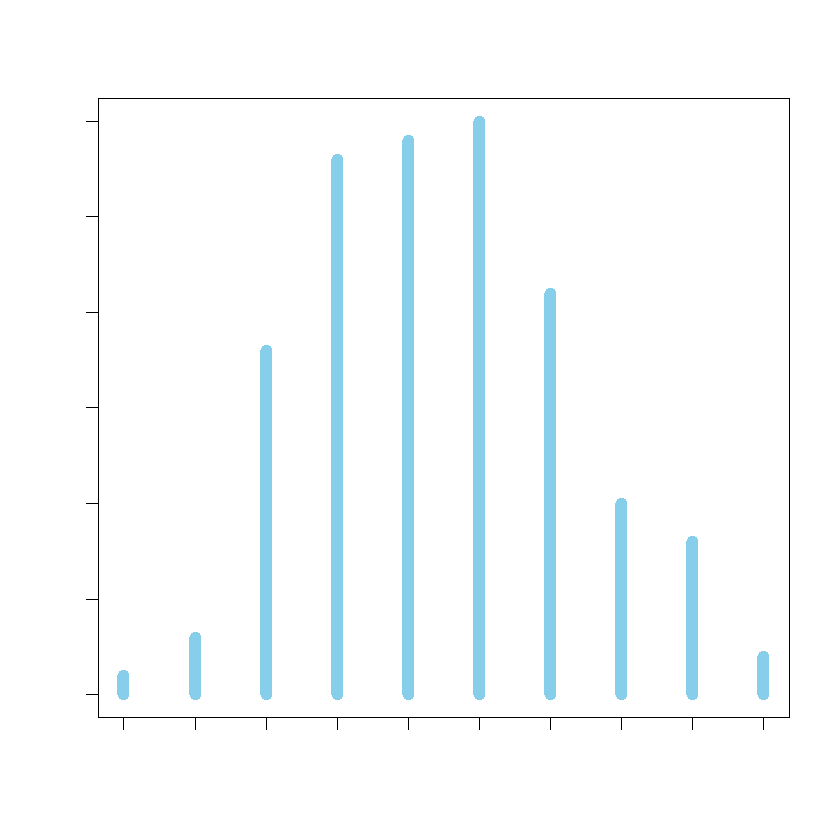

In [78]:
data <- rhyper(150, m = 20, n = 80, k = 40)
plot(table(data),lwd=10,col = "skyblue",main = "Hypergeometric Distribution Simulation",xlab ="Number of Success",col.main='white',col.lab='white',col.axis='white')

Q1-2 and Q1-3:


[1] "Theorical Mean: "
[1] 8
[1] "theorical Var: "
[1] 3.878788


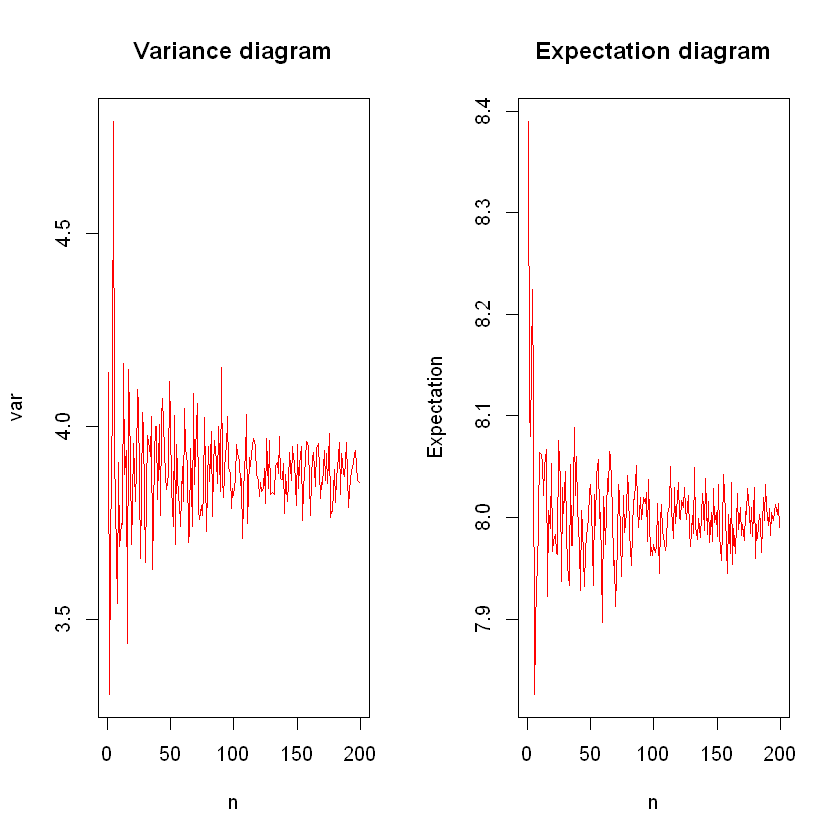

In [79]:
calcVarAndMean <- function() {
  n <- 40
  K <- 20
  N <- 100
  sample <- seq(100, 10000, by = 50)
  vars <- c()
  expcs <- c()
  
  for (i in sample) {
    currSample <- i
    data <- rhyper(currSample, m = 20, n = 80, k = 40)
    var_value <- var(data)
    expectation <- mean(data)
    vars <- c(vars, var_value)
    expcs <- c(expcs, expectation)
  }
  
  theoricalVar <- n * (K / N) * ((N - K) / N) * ((N - n) / (N - 1))
  theoricalMean <- n * (K / N)
  
  return(list(
    sample_sizes = sample,
    vars = vars,
    expcs = expcs,
    theoricalVar = theoricalVar,
    theoricalMean = theoricalMean
  ))
}
data<-calcVarAndMean()
vars <- data$vars 
expcs <- data$expcs
theoricalVar<-data$theoricalVar
theoricalMean<-data$theoricalMean
par(bg='white',mfrow = c(1,2))
print("Theorical Mean: ")
print(theoricalMean)
print("theorical Var: ")
print(theoricalVar)
plot(vars, type="l", col="#ff0000", main="Variance diagram", xlab="n", ylab="var",col.main='black',col.lab='black',col.axis='black')
plot(expcs, type="l", col="#ff0000", main="Expectation diagram", xlab="n", ylab="Expectation",col.main='black',col.lab='black',col.axis='black')


<p>Q1 - 4: </p>

    we will simulate the hypergeomatric distribution by the variables given then simulate it again with the binomial distributation and compare their diagram.

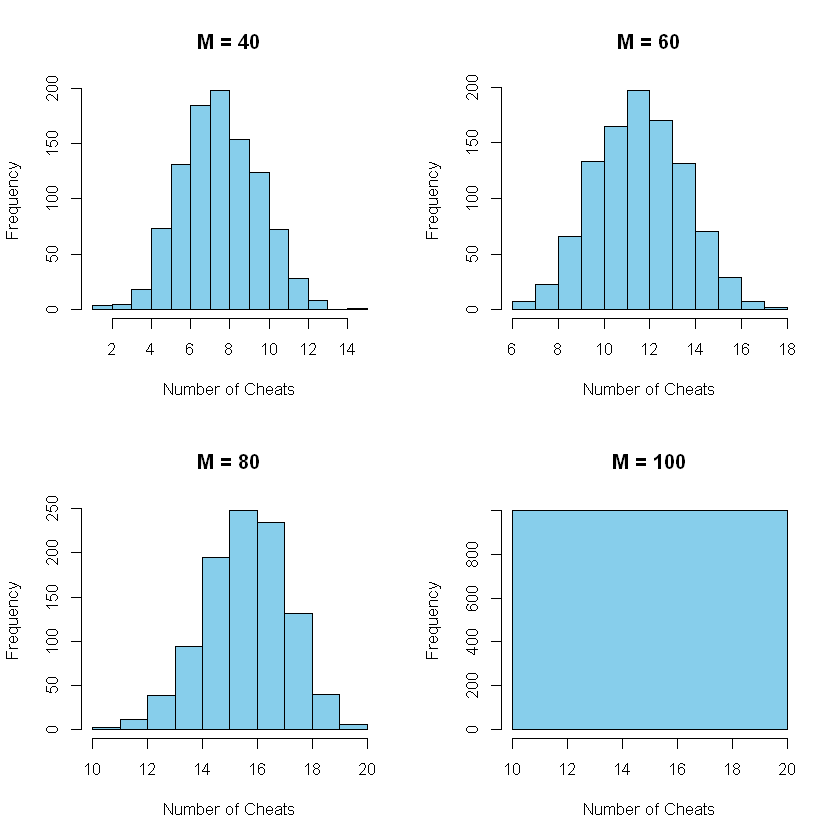

In [80]:
currSample <- 1000
theM <- seq(40, 100, by = 20)
result <- list()

for (i in theM) {
  mm <- i
  data <- rhyper(currSample, m = 20, n = 80, k = mm)
  result[[as.character(i)]] <- data
}
par(mfrow = c(2, 2),bg = 'white')
hist(result[['40']], main = "M = 40", xlab = "Number of Cheats", col = "skyblue", border = "black")
hist(result[['60']], main = "M = 60", xlab = "Number of Cheats", col = "skyblue", border = "black")
hist(result[['80']], main = "M = 80", xlab = "Number of Cheats", col = "skyblue", border = "black")
hist(result[['100']], main = "M = 100", xlab = "Number of Cheats", col = "skyblue", border = "black")


    as we can see the histograms are a lot like a binomial distribution
    * Note that the P in binommial distribution will equall to K/N

<p>Q1-5:</p>

In [81]:
binomialPmf<-function(n,p,k)
{
    PXk<-choose(n,k)*p^k*(1-p)^(n-k)
    return (PXk)
}
hyperGeometricPmf <- function(n, K, N, x) {
  PXx <- (choose(K, x) * choose(N - K, n - x)) / choose(N, n)
  return(PXx)
}
simulate<-function(N,K,n)
{
    result=list()
    x=seq(0,20)
    binomialRes<-c()
    hyperRes<-c()
    for (i in x)
    {
        binPmf <- binomialPmf(K,K/N,i)
        hyperPmf<-hyperGeometricPmf(n,K,N,i)
        binomialRes<-c(binomialRes,binPmf)
        hyperRes<-c(hyperRes,hyperPmf)
    }
    result[["hyper"]]=hyperRes
    result[["binom"]]=binomialRes
    return (result)

}
binomialRes=simulate(100,20,40)[["binom"]]
hyperRes=simulate(100,20,40)[["hyper"]]

print(binomialRes)
print(hyperRes)



 [1] 1.152922e-02 5.764608e-02 1.369094e-01 2.053641e-01 2.181994e-01
 [6] 1.745595e-01 1.090997e-01 5.454985e-02 2.216088e-02 7.386959e-03
[11] 2.031414e-03 4.616849e-04 8.656592e-05 1.331783e-05 1.664729e-06
[16] 1.664729e-07 1.300570e-08 7.650410e-10 3.187671e-11 8.388608e-13
[21] 1.048576e-14
 [1] 7.820848e-06 1.526019e-04 1.346167e-03 7.137815e-03 2.550958e-02
 [6] 6.530452e-02 1.242206e-01 1.797234e-01 2.007847e-01 1.748329e-01
[11] 1.192361e-01 6.376259e-02 2.666993e-02 8.670631e-03 2.167658e-03
[16] 4.098844e-04 5.718253e-05 5.665142e-06 3.744203e-07 1.469625e-08
[21] 2.571843e-10


<P>Q1-6 and Q1-7</p>

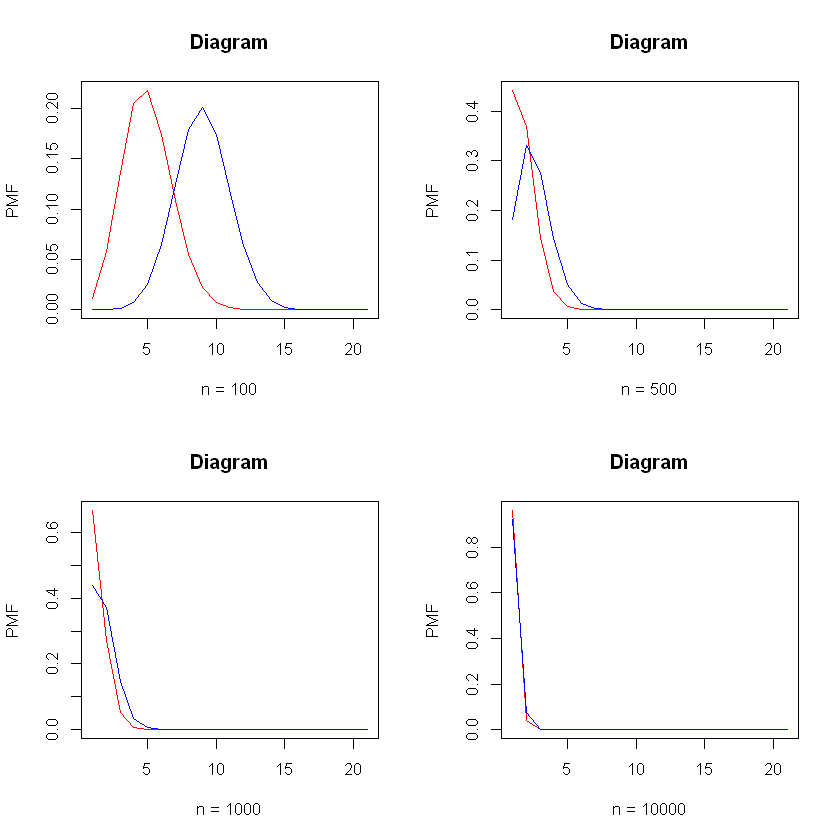

In [82]:
N<-c(100,500,1000,10000)
K<-20
n<-40
par(mfrow = c(2, 2),bg = 'white')
for (i in N)
{
    binomialRes=simulate(i,20,40)[["binom"]]
    hyperRes=simulate(i,20,40)[["hyper"]]
    plot(binomialRes, type = "l", col = "#ff0000", main = "Diagram", xlab=paste("n =", as.character(i)), ylab = "PMF", col.main = 'black', col.lab = 'black', col.axis = 'black')
    lines(hyperRes, type = "l", col = "#0000ff") 
}

    as you can see the more our N gets ,the more similar our diagrams become.

<p>Q2-1 : </p>

    as we know the cdf for a discrete function for 'x' is the sum of its pmf value from 0 to x (p{X<x>}) 

In [83]:
binomialPmf<-function(n,p,k)
{
    PXk<-choose(n,k)*p^k*(1-p)^(n-k)
    return (PXk)
}
binomialCdf<-function(n,p,k) # Fx(k)
{
    cdf<-0
    for (i in 0:k)
    {
        cdf=cdf+ binomialPmf(n,p,i)
    }
    return (cdf)
}
n<-1000
p<-0.45
x<-430
print(binomialCdf(n,p,x))

[1] 0.1074638


<p>Q2-2 :</p>

    as we know of the n is high enough and our p is around 0.5 we can aproximate it into a normal distribution with the mean of np and var of np(1-p).

In [84]:
n<-1000
p<-0.45
x<-430
mean<-n*p
var<- n*p*(1-p)
theActualCdf<-binomialCdf(n,p,x)
approximatedCdf<-pnorm(x, mean = mean, sd = sqrt(var))
print(paste("the actuall cdf is :",theActualCdf))
print(paste("the approximated cdf is :",approximatedCdf))
print(paste("the error is : ",abs(theActualCdf-approximatedCdf)))

[1] "the actuall cdf is : 0.107463797278376"
[1] "the approximated cdf is : 0.101813913546803"
[1] "the error is :  0.00564988373157276"


<p>Q2-3</p>

In [85]:
n<-1000
p<-0.45
x<-430
mean<-n*p
var<- n*p*(1-p)
theActualCdf<-binomialCdf(n,p,x)
approximatedCdf<-pnorm(x+0.5, mean = mean, sd = sqrt(var))
print(paste("the actuall cdf is :",theActualCdf))
print(paste("the approximated cdf is :",approximatedCdf))
print(paste("the error is : ",abs(theActualCdf-approximatedCdf)))

[1] "the actuall cdf is : 0.107463797278376"
[1] "the approximated cdf is : 0.107579941598096"
[1] "the error is :  0.000116144319720096"


    as you can see the error reduced and our approximate got more precise !

<p>Q2-4</p>

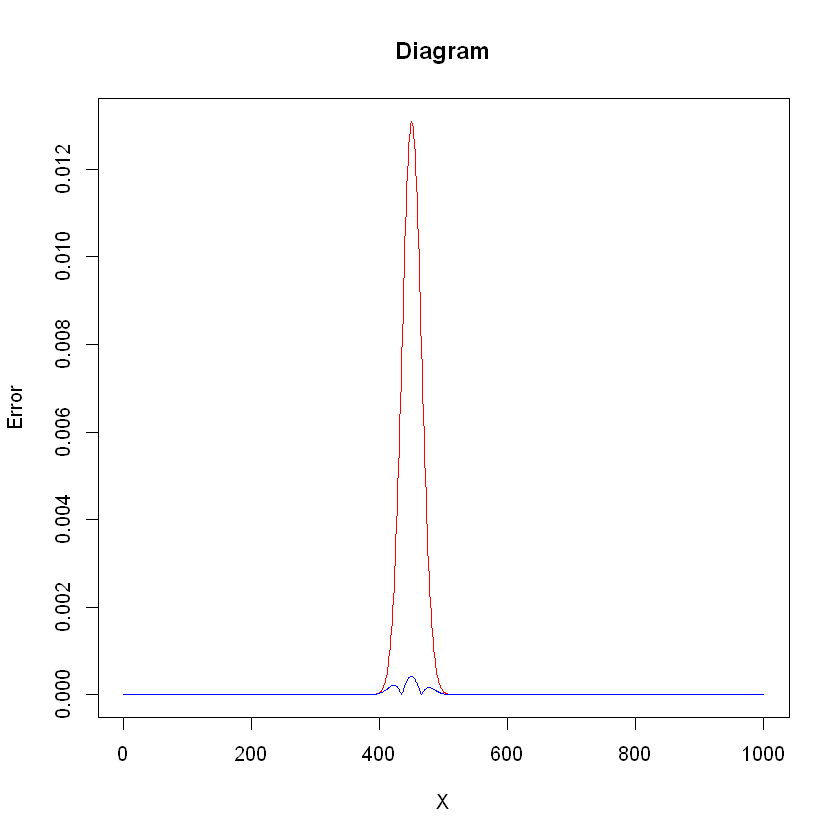

In [86]:
n<-1000
p<-0.45
x<-430
mean<-n*p
var<- n*p*(1-p)
firstPartErr<-c()
secondPartErr<-c()
X<-seq(0,1000)
for (i in X )
{
    theActualCdf<-binomialCdf(n,p,i)
    approximatedCdfNoCorrection<-pnorm(i, mean = mean, sd = sqrt(var))
    approximatedCdfWithCorrection<-pnorm(i+0.5, mean = mean, sd = sqrt(var))
    err1<-abs(theActualCdf-approximatedCdfNoCorrection)
    err2<-abs(theActualCdf-approximatedCdfWithCorrection)
    firstPartErr<-c(firstPartErr,err1)
    secondPartErr<-c(secondPartErr,err2)
}
par(mfrow = c(1,1),bg = 'white')
plot(firstPartErr, type = "l", col = "#ff0000", main = "Diagram", xlab="X", ylab = "Error", col.main = 'black', col.lab = 'black', col.axis = 'black')
lines(secondPartErr, type = "l", col = "#0000ff") 

    we can see that around X=500 the error in the not corrected approximate increases a lot compare to the err in the corrected approximate

Q2-5:

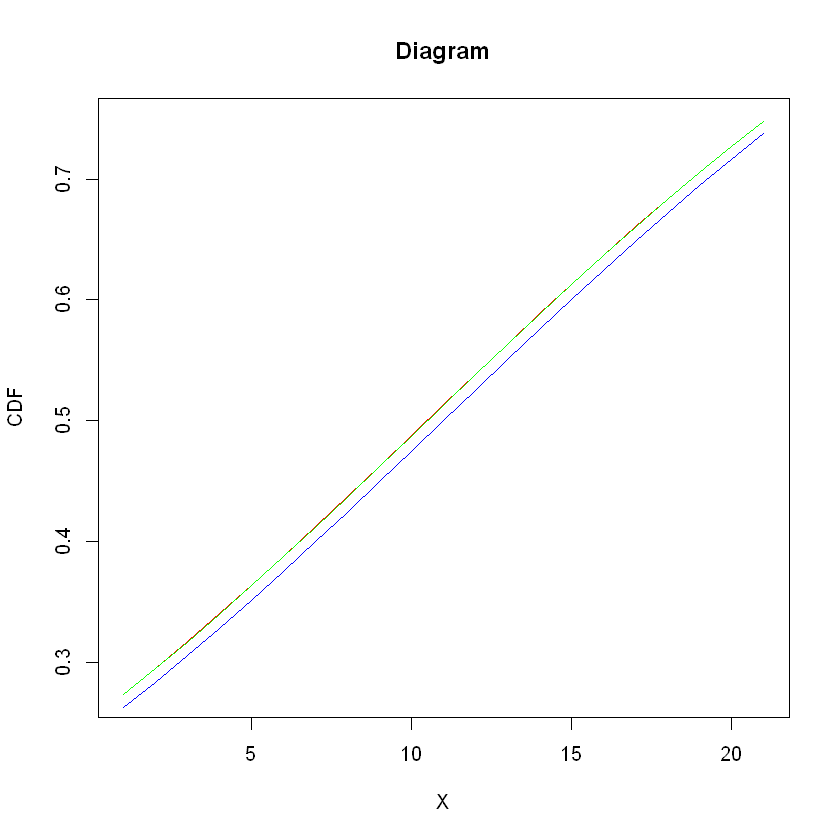

In [87]:
n<-1000
p<-0.45
mean<-n*p
var<- n*p*(1-p)
theActualCdfs<-c()
approximatedCdfNoCorrections<-c()
approximatedCdfWithCorrections<-c()

for (i in 440:460 )
{
    theActualCdf<-binomialCdf(n,p,i)
    approximatedCdfNoCorrection<-pnorm(i, mean = mean, sd = sqrt(var))
    approximatedCdfWithCorrection<-pnorm(i+0.5, mean = mean, sd = sqrt(var))
    theActualCdfs<-c(theActualCdfs,theActualCdf)
    approximatedCdfNoCorrections<-c(approximatedCdfNoCorrections,approximatedCdfNoCorrection)
    approximatedCdfWithCorrections<-c(approximatedCdfWithCorrections,approximatedCdfWithCorrection) 
}
par(mfrow = c(1,1),bg = 'white')
plot(theActualCdfs, type = "l", col = "#ff0000", main = "Diagram", xlab="X", ylab = "CDF", col.main = 'black', col.lab = 'black', col.axis = 'black')
lines(approximatedCdfNoCorrections, type = "l", col = "#0000ff") 
lines(approximatedCdfWithCorrections, type = "l", col = "#11ff00") 

    as its shown the cdfs increase in a linear expression and also the green line (which represents the corrected normal) is almost exactly on the red line(which represents the actual cdf) so around 440 to 460 the error gets almost to zero

Q2-6:

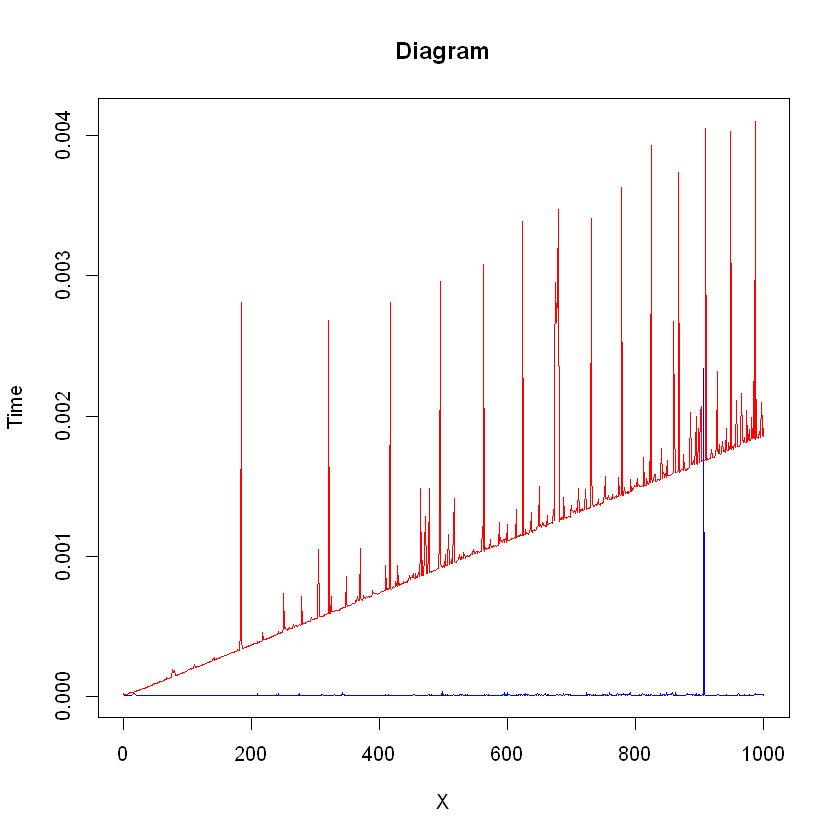

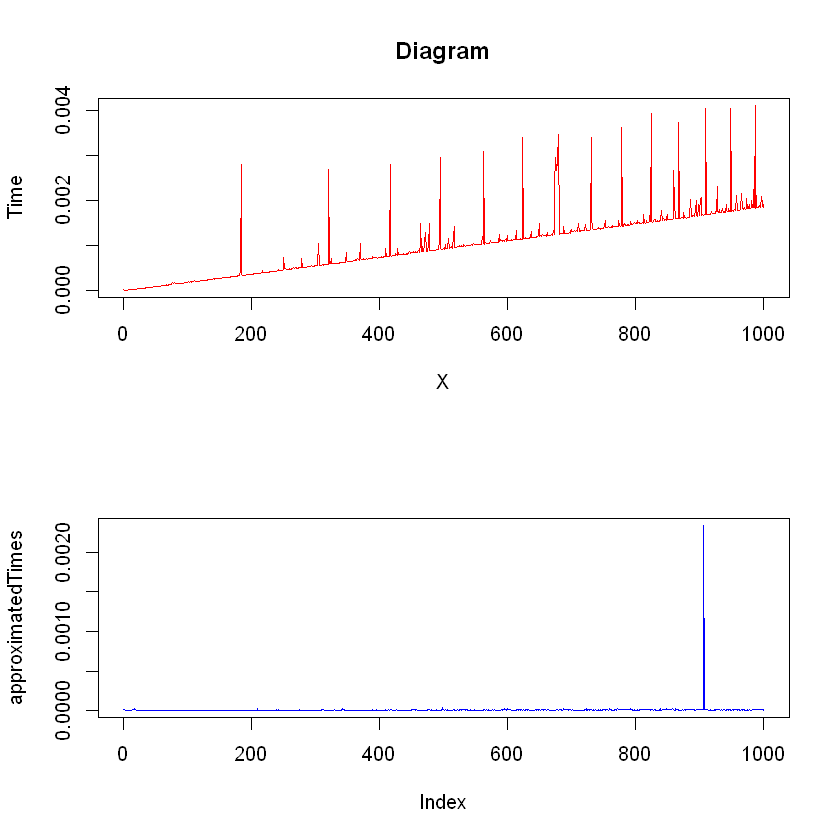

In [88]:
n <- 1000
p <- 0.45
mean <- n * p
var <- n * p * (1 - p)
theActualCdfs <- c()
approximatedCdfWithCorrections <- c()
actualTimes <- c()
approximatedTimes <- c()
for (i in 0:1000)
{
    start <- Sys.time()
    theActualCdf <- binomialCdf(n, p, i)
    theActualCdfs <- c(theActualCdfs, theActualCdf)
    end<-Sys.time()
    time<-abs(start-end)
    actualTimes <- c(actualTimes, time)
}

for (i in 0:1000)
{
    start <- Sys.time()
    approximatedCdfWithCorrection <- pnorm(i + 0.5, mean = mean, sd = sqrt(var))
    approximatedCdfWithCorrections <- c(approximatedCdfWithCorrections, approximatedCdfWithCorrection)
    end <- Sys.time()
    time <- abs(start - end)
    approximatedTimes <- c(approximatedTimes, time)
}
par(mfrow = c(1,1),bg = 'white')
plot(actualTimes, type = "l", col = "#ff0000", main = "Diagram", xlab="X", ylab = "Time", col.main = 'black', col.lab = 'black', col.axis = 'black')
lines(approximatedTimes, type = "l", col = "#0000ff") 
par(mfrow = c(2,1),bg = 'white')
plot(actualTimes, type = "l", col = "#ff0000", main = "Diagram", xlab="X", ylab = "Time", col.main = 'black', col.lab = 'black', col.axis = 'black')
plot(approximatedTimes, type = "l", col = "#0000ff") 

    we can see that the time taken by the normal cdf calculator is much less than the binomial calculator (its visible in the mixed diagram)

Q2-7:

    what were gonna do is that we copy the code from the previouse section then implement the binomial cdf ,normal cdf,and thir times for X from 400 to 600 then calculate the cost for each X and return the first X that has more timing cost which means the binomial cost has gone too far

In [89]:
n <- 1000
p <- 0.45
mean <- n * p
var <- n * p * (1 - p)
theActualCdfs <- c()
approximatedCdfWithCorrections <- c()
actualTimes <- c()
approximatedTimes <- c()
for (i in 400:600)
{
    start <- Sys.time()
    theActualCdf <- binomialCdf(n, p, i)
    theActualCdfs <- c(theActualCdfs, theActualCdf)
    end <- Sys.time()
    time <- abs(start - end)
    actualTimes <- c(actualTimes, time)
}

for (i in 400:600)
{
    start <- Sys.time()
    approximatedCdfWithCorrection <- pnorm(i + 0.5, mean = mean, sd = sqrt(var))
    approximatedCdfWithCorrections <- c(approximatedCdfWithCorrections, approximatedCdfWithCorrection)
    end <- Sys.time()
    time <- abs(start - end)
    approximatedTimes <- c(approximatedTimes, time)
}
firstNotGoodBin <- function() {
    for (i in 1:201)
    {
        timeCost <- (actualTimes[i] - approximatedTimes[i]) * TIMECOST
        errCost <- abs(approximatedCdfWithCorrections[i] - theActualCdfs[i]) * ERRCOST
        if (timeCost > errCost) {
            return (i+400)
        }
    }
}
TIMECOST <- 100
ERRCOST <- 10^6
print(firstNotGoodBin())


[1] 525


Q2-8:

    now instead of returning the first not good X we append all the cost differances to the result

[1] "X=430 cost -115.992733187503"


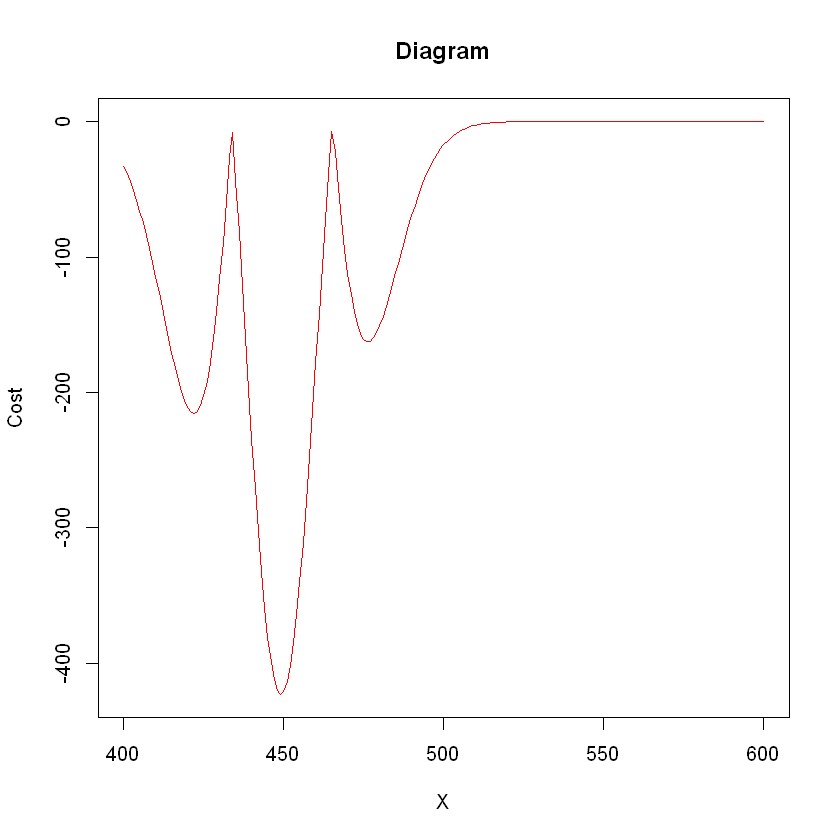

In [90]:

makeResult <- function() {
    result<-c()
    for (i in 1:201)
    {
        timeCost <- (actualTimes[i] - approximatedTimes[i]) * TIMECOST
        errCost <- abs(approximatedCdfWithCorrections[i] - theActualCdfs[i]) * ERRCOST
        result<-c(result,(timeCost-errCost))
    }
    return (result)
}
result=makeResult()
TIMECOST <- 100
ERRCOST <- 10^6
print (paste("X=430 cost",result[31]))
par(mfrow = c(1,1),bg = 'white')
plot(400:600,result, type = "l", col = "#ff0000", main = "Diagram", xlab="X", ylab = "Cost", col.main = 'black', col.lab = 'black', col.axis = 'black')


    since the cost is negative it means that the time cost had been less than the err cost so the binomal was indeed the better choice. 
    however we proved that the first X that is not good to calculate by binomial is 525 so binomial would still be a better choice 

Q3-1:

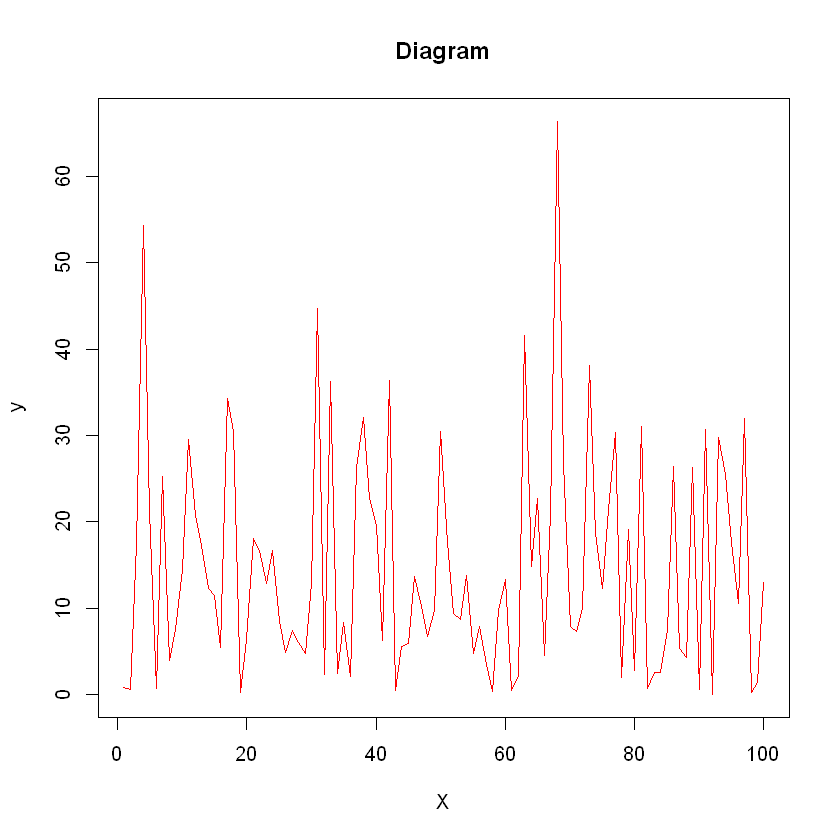

In [91]:
exponentialDistributation<-function(landa,sampleSize)
{
    data<-rexp(sampleSize,rate = landa)
    return (data)
}
data<-exponentialDistributation(1/15,100)
par(mfrow = c(1,1),bg = 'white')
plot(data, type = "l", col = "#ff0000", main = "Diagram", xlab="X", ylab = "y", col.main = 'black', col.lab = 'black', col.axis = 'black')


Q3-2:

In [92]:
findMoreThan12 <- function(data) {
    bigger12 <- c()
    for (i in data)
    {
        if (i > 12 & i < 4800) {
            bigger12 <- c(bigger12, i-12)
        }
    }
    return (bigger12)
}
data <- exponentialDistributation(1 / 15, 100)


Q3-3:

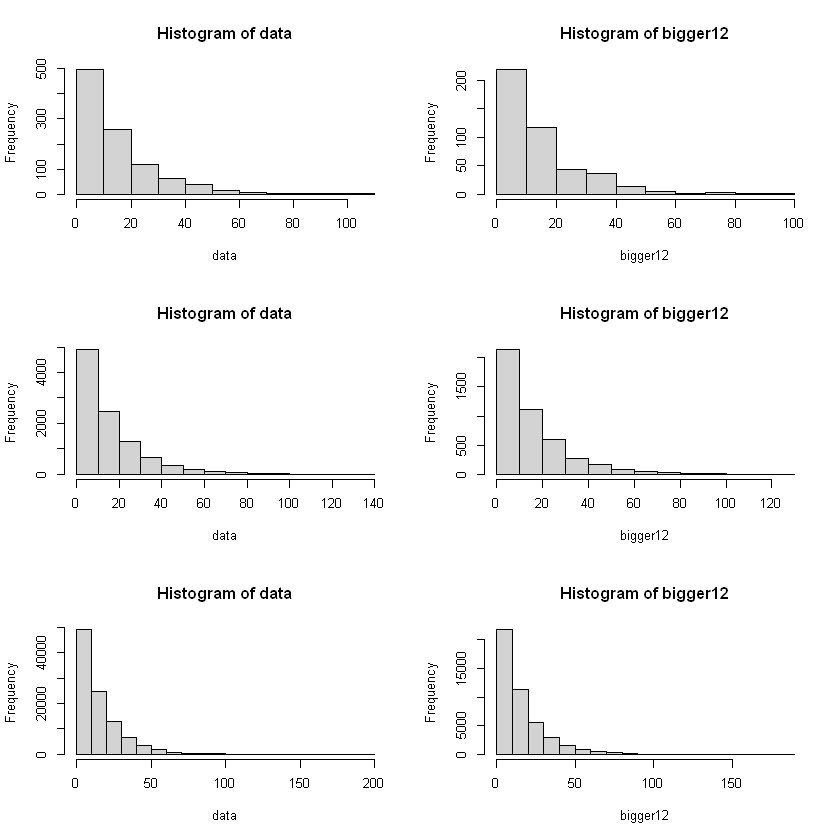

In [93]:
findMoreThan12 <- function(data) {
    bigger12 <- c()
    for (i in data)
    {
        if (i > 12 & i < 4800) {
            bigger12 <- c(bigger12, i - 12)
        }
    }
    return (bigger12)
}
M <- c(10, 100, 1000)
par(mfrow = c(3,2),bg = 'white')
for (i in M)
{
    data <- exponentialDistributation(1 / 15, 100 * i)
    bigger12 <- findMoreThan12(data)
    hist(data)
    hist(bigger12)
}


Q3-4:

    by comparing these two diagrams for each m ,since they look exactly a like we can conclude that it doesnt matter how long has it taken so far it still is a exponential distribution . it proves the memorylessness of the exp distribution.

Q3-5:

    when we want to calculate the probability that no customer has entered the stor for at least 12 minutes and at most 15 minuts we should calculate P{12<X<15}:
    in theorical we use cdf function so the P would be : Fx(15)-Fx(12)
    but in simulation we should find the datas that are less than 3=15-12 in our bigger 12 vector:

In [94]:

experimentalcalculation <- function() {
    matloob <- c()
    M <- 1000
    data <- exponentialDistributation(1 / 15, M)
    bigger12 <- findMoreThan12(data)
    return(mean(bigger12 < 3))
}
theorical <- function() {
    p <- 1 - exp(3 * -(1/15))
    return(p)
}
print(experimentalcalculation())
print(theorical())


[1] 0.1865169
[1] 0.1812692


Q4-1:

In [95]:
uniformDistribution<-function(sampleZize,min,max)
{
    return(runif(sampleZize,min,max))
}
data<-uniformDistribution(10^6,0,1)

Q4-2:

In [100]:
X<-uniformDistribution(10^6,0,1)
Y<--2*log(X)

Q4-3:

    we know that the fx(X) in exponential distribution is landa*e^(-landa*x)

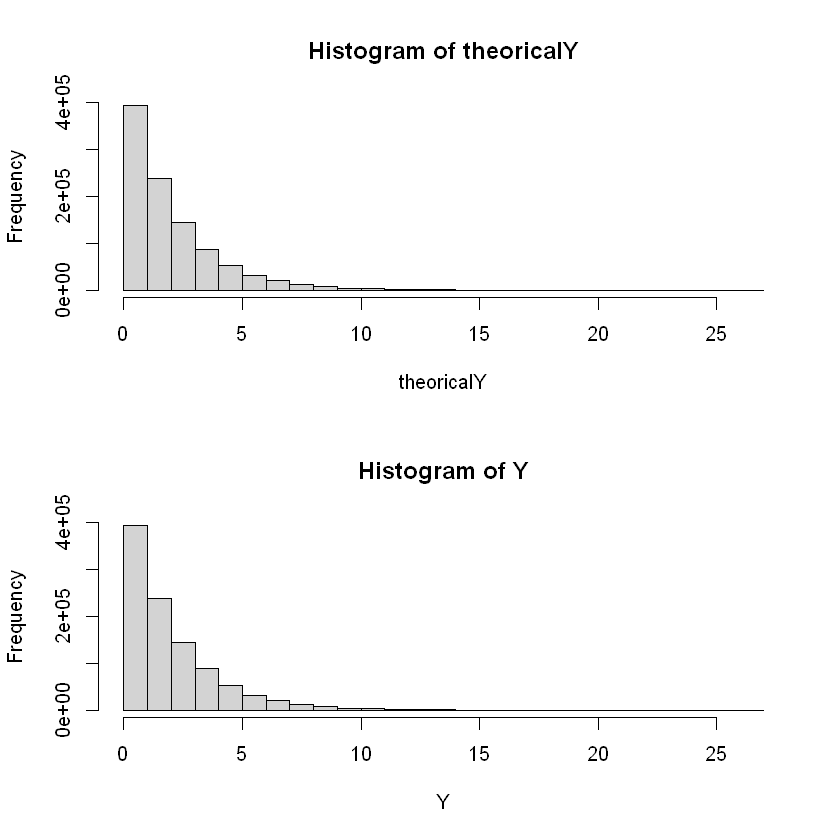

In [101]:
sampleSize<-10^6
theoricalY<-rexp(sampleSize,0.5)
par(mfrow = c(2,1),bg = 'white')
hist(theoricalY)
hist(Y)

    as we can see the histograms are almost the same so when we use -2Ln(x) we indees have a exponential distribution

Q4-4:

In [98]:
u1<-runif(10^6,0,1)
u2<-runif(10^6,0,1)

Q4-5 and Q4-6:

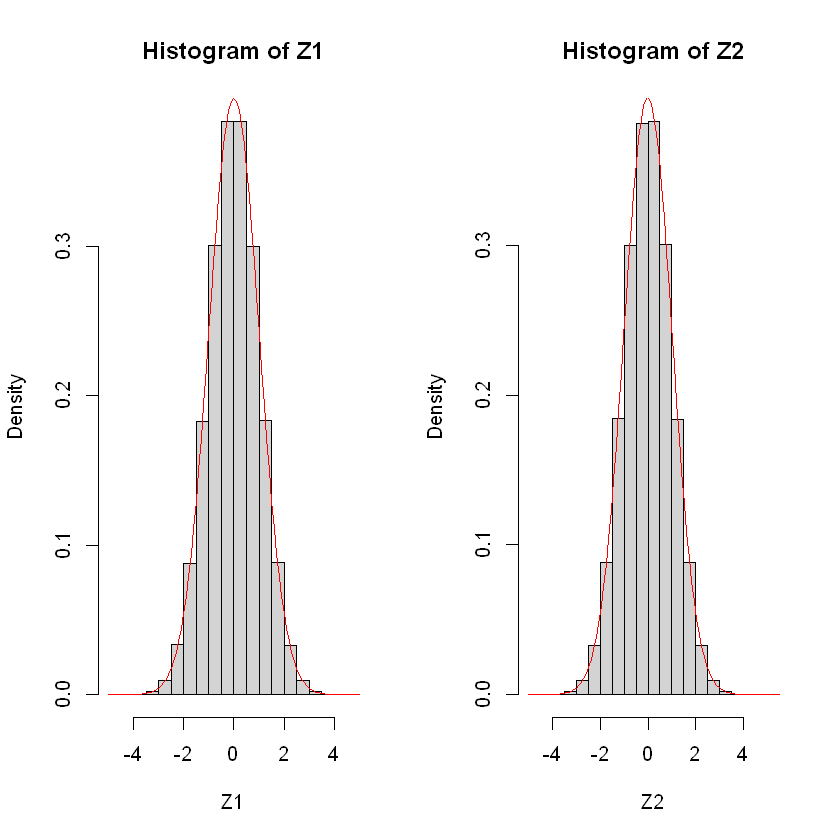

In [99]:
Z1<-sqrt(-2*log(u1))*cos(2*3.14*u2)
Z2<-sqrt(-2*log(u1))*sin(2*3.14*u2)
par(mfrow = c(1,2),bg = 'white')
hist(Z1,prob=TRUE)
curve (dnorm(x),add=TRUE,col='red')
hist(Z2,prob=TRUE)
curve (dnorm(x),add=TRUE,col='red')

as you can see the histograms are for z and the curve is a normal distribution and 